# Notebook 2 — From Eigenvalues to Singular Values

## What this notebook teaches

The adjoint pattern from Notebook 1 generalizes to *singular value* objectives, with one structural change worth understanding clearly. The Hellmann-Feynman integrand is $|\psi^*|^2$ — the eigenvector squared, hence quadratic in *one* vector. The SVD analog is $\tilde u_k(x)\,\tilde v(x)$ — bilinear in *two different* vectors (left and right singular vectors). This sounds minor and is computationally minor, but conceptually it's the moment to internalize: eigenvalue derivatives use one vector, singular-value derivatives use two.

The application is multi-gap optimization. Single-gap notebooks ask "best one rectangle"; multi-gap asks "best collection of $K$ rectangles together." When $K$ gaps each remove a piece of a bandlimited function and you want to recover the function from the complement, the conditioning quantity is $\sigma_\min(A_\mathrm{stack})$ where $A_\mathrm{stack} = [I - K^{(1)};\,I - K^{(2)};\,\ldots]$ stacks the $K$ "what's left after removing gap $k$" operators. Larger $\sigma_\min$ means recovery is more stable.

Three things by the end:
1. The pattern from Notebook 1 transfers essentially unchanged — same Reynolds-transport edge structure, slightly different integrand.
2. Verification by FD scales to higher-DOF problems — costs $2d$ forward solves, still negligible.
3. A specific but instructive finding: in this framework, *position diversity* improves conditioning much more than *shape diversity*. Different-shaped gaps optimally placed do worse than same-shaped gaps optimally placed. The lesson generalizes: when your design space has multiple kinds of variation, optimize over each separately and compare; the expensive variable is often not the most useful one.


## Setup

Three rectangular gaps $G_1, G_2, G_3$ with centroids $(x_0^{(k)}, y_0^{(k)})$ and shapes $(a_k, b_k)$. Each contributes a coupling matrix $K^{(k)} \in \mathbb{R}^{N \times N}$ where $N = M_x N_y$.

The stacked recovery operator: each "experiment" $k$ produces a measurement $(I - K^{(k)})\,\hat f$ — the bandlimited function with gap $k$'s contribution subtracted. Stacking $K$ experiments:

$$A_\mathrm{stack}(z) = \begin{pmatrix} I - K^{(1)} \\ I - K^{(2)} \\ I - K^{(3)} \end{pmatrix} \in \mathbb{R}^{KN \times N}.$$

$\sigma_\min(A_\mathrm{stack})$ controls the recovery problem's worst-case sensitivity to noise. Larger is better. We maximize.

Same numerical setup as Notebook 1: $L=1$, $W=\sqrt 2$, sine basis. To keep the SVD compute light, $M_x = N_y = 10$ (so $N = 100$, $A_\mathrm{stack}$ is $300 \times 100$). Three gaps, the framework's hand-picked configuration uses mixed shapes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 10, 10
N = Mx * Ny

# Framework's hand-picked 3-gap configuration (full widths)
gaps_std = [
    ("A: upper-right", 0.675, 0.86, 0.15, 0.12),
    ("B: lower-left",  0.20,  0.20, 0.20, 0.10),
    ("C: center",      0.46,  0.64, 0.12, 0.18),
]
positions_std = [(g[1], g[2]) for g in gaps_std]
sizes_std     = [(g[3], g[4]) for g in gaps_std]

def build_J_1d(M, x0, half, L_dom):
    x_lo, x_hi = x0-half, x0+half
    Jm = np.zeros((M, M)); ks = np.arange(1, M+1)*np.pi/L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]; kp, kd = km+kn, km-kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo)) / k
            Jm[m, n] = 0.5*(Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return Jm

def K_single(x0, y0, a_w, b_w):
    """Half-widths a_w/2, b_w/2 (a_w, b_w are full widths)."""
    return (4/(L*W)) * np.kron(build_J_1d(Mx, x0, a_w/2, L),
                               build_J_1d(Ny, y0, b_w/2, W))

def A_stack(positions, sizes):
    return np.vstack([np.eye(N) - K_single(p[0], p[1], s[0], s[1])
                      for p, s in zip(positions, sizes)])

def sigma_min(positions, sizes):
    return svd(A_stack(positions, sizes), compute_uv=False)[-1]

print(f"At the framework's hand-picked configuration: sigma_min = {sigma_min(positions_std, sizes_std):.6f}")


At the framework's hand-picked configuration: sigma_min = 1.426206


## The pattern, generalized

For $A(z)$ smoothly parametrized with smallest singular value $\sigma$ and corresponding singular vectors $u, v$ (so $A v = \sigma u$, $A^\top u = \sigma v$, both unit norm):

$$\frac{\partial \sigma}{\partial z} = u^\top \frac{\partial A}{\partial z}\,v.$$

Same logic as Hellmann-Feynman: the first-order changes in $u$ and $v$ drop out because they're orthogonal to $u$ and $v$ themselves. **One vector becomes two**: derivatives of singular values use both left and right singular vectors. The integrand at a moving boundary becomes $u_k(x)\,v(x)$ — bilinear, not quadratic.

For our $A_\mathrm{stack}$, the position $x_0^{(k)}$ only affects the $k$-th block $-K^{(k)}$. The left singular vector $u$ has length $KN$; let $u_k \in \mathbb{R}^N$ be its $k$-th block. Reynolds transport on $K^{(k)}$ then gives:

$$\boxed{\;\frac{\partial \sigma}{\partial x_0^{(k)}} = -\int_{\partial G_k^R}\!\!u_k^*(x,y)\,v^*(x,y)\,dS \;+\; \int_{\partial G_k^L}\!\!u_k^*(x,y)\,v^*(x,y)\,dS\;}$$

where $u_k^*, v^*$ are the corresponding singular vectors reconstructed in physical space via the sine basis. Note the leading minus sign — $A = I - K$ so $\partial A/\partial z = -\partial K/\partial z$, and the gradient flips sign accordingly. This is the kind of detail FD verification catches.

The bilinear edge integrals factorize over $x$ and $y$ in the sine basis, so each one reduces to a vector-matrix-vector contraction — same cost as Notebook 1's quadratic ones, just with two distinct vectors instead of one squared.


In [2]:
def adjoint_grad(positions, sizes):
    """Returns grads of shape (K_gaps, 2) giving (d sigma_min/d x_0^k, d sigma_min/d y_0^k), and sigma_min."""
    A = A_stack(positions, sizes)
    U, S, Vt = svd(A, full_matrices=False)
    sigma = S[-1]
    v_min = Vt[-1, :]; u_min = U[:, -1]
    Vmat = v_min.reshape(Mx, Ny)
    Kg = len(positions)
    grads = np.zeros((Kg, 2))
    pre = 4.0/(L*W)
    for k, ((x0, y0), (aa, bb)) in enumerate(zip(positions, sizes)):
        u_k_mat = u_min[k*N:(k+1)*N].reshape(Mx, Ny)
        Jx_k = build_J_1d(Mx, x0, aa/2, L)
        Jy_k = build_J_1d(Ny, y0, bb/2, W)
        sx_R = np.sin(np.arange(1,Mx+1)*np.pi*(x0+aa/2)/L)
        sx_L = np.sin(np.arange(1,Mx+1)*np.pi*(x0-aa/2)/L)
        sy_T = np.sin(np.arange(1,Ny+1)*np.pi*(y0+bb/2)/W)
        sy_B = np.sin(np.arange(1,Ny+1)*np.pi*(y0-bb/2)/W)
        # bilinear edge integrals
        e_R = pre * (u_k_mat.T @ sx_R) @ Jy_k @ (Vmat.T @ sx_R)
        e_L = pre * (u_k_mat.T @ sx_L) @ Jy_k @ (Vmat.T @ sx_L)
        e_T = pre * (u_k_mat   @ sy_T) @ Jx_k @ (Vmat   @ sy_T)
        e_B = pre * (u_k_mat   @ sy_B) @ Jx_k @ (Vmat   @ sy_B)
        grads[k, 0] = -(e_R - e_L)   # minus from A = I - K
        grads[k, 1] = -(e_T - e_B)
    return grads, sigma

g_std, sig_std = adjoint_grad(positions_std, sizes_std)
print(f"At standard config:  sigma_min = {sig_std:.6f}")
for k, lab in enumerate([g[0] for g in gaps_std]):
    print(f"  d/d position of {lab}: ({g_std[k,0]:+.4f}, {g_std[k,1]:+.4f})")


At standard config:  sigma_min = 1.426206
  d/d position of A: upper-right: (+0.0010, +0.0003)
  d/d position of B: lower-left: (+0.0001, +0.0001)
  d/d position of C: center: (+0.0568, -0.0007)


## Verification

Six DOFs, centered FD. Twelve forward SVDs.


In [3]:
def fd_grad(positions, sizes, h=1e-6):
    Kg = len(positions); out = np.zeros((Kg, 2))
    for k in range(Kg):
        for d in range(2):
            pp = [list(p) for p in positions]; pm = [list(p) for p in positions]
            pp[k][d] += h; pm[k][d] -= h
            out[k, d] = (sigma_min(pp, sizes) - sigma_min(pm, sizes)) / (2*h)
    return out

g_adj, _ = adjoint_grad(positions_std, sizes_std)
g_fd = fd_grad(positions_std, sizes_std)
print(f"{'gap':<20} {'adj_x':>10} {'fd_x':>10} {'rel':>10}    {'adj_y':>10} {'fd_y':>10} {'rel':>10}")
for k, lab in enumerate([g[0] for g in gaps_std]):
    rx = abs(g_adj[k,0] - g_fd[k,0]) / (abs(g_fd[k,0]) + 1e-15)
    ry = abs(g_adj[k,1] - g_fd[k,1]) / (abs(g_fd[k,1]) + 1e-15)
    print(f"{lab:<20} {g_adj[k,0]:>+10.4f} {g_fd[k,0]:>+10.4f} {rx:>10.2e}    "
          f"{g_adj[k,1]:>+10.4f} {g_fd[k,1]:>+10.4f} {ry:>10.2e}")


gap                       adj_x       fd_x        rel         adj_y       fd_y        rel
A: upper-right          +0.0010    +0.0010   1.75e-07       +0.0003    +0.0003   9.36e-08
B: lower-left           +0.0001    +0.0001   9.28e-07       +0.0001    +0.0001   2.26e-07
C: center               +0.0568    +0.0568   9.19e-10       -0.0007    -0.0007   8.40e-08


Relative errors at $10^{-7}$–$10^{-9}$. Six gradients, all signs and magnitudes match. The leading minus sign in the adjoint formula is doing the right thing.

## Optimization

Six DOFs, multi-start L-BFGS, maximize $\sigma_\min$ (minimize negative).


In [4]:
def pack(positions): return np.array([c for p in positions for c in p])
def unpack(z): return [(z[2*k], z[2*k+1]) for k in range(len(z)//2)]

def make_bounds(sizes):
    bnds = []
    for (aa, bb) in sizes:
        bnds.append((aa/2 + 0.005, L - aa/2 - 0.005))
        bnds.append((bb/2 + 0.005, W - bb/2 - 0.005))
    return bnds

def neg_sigma_and_grad(z, sizes):
    positions = unpack(z)
    grads, sig = adjoint_grad(positions, sizes)
    return -sig, -grads.flatten()

bounds_std = make_bounds(sizes_std)
np.random.seed(0)
best = (-np.inf, None)
for trial in range(20):
    z0 = np.array([np.random.uniform(*b) for b in bounds_std])
    res = minimize(lambda z: neg_sigma_and_grad(z, sizes_std), z0, jac=True,
                   method="L-BFGS-B", bounds=bounds_std,
                   options={"gtol": 1e-9, "ftol": 1e-12})
    if -res.fun > best[0]:
        best = (-res.fun, res.x.copy())

opt_global = unpack(best[1])
print(f"Hand-picked configuration:  sigma_min = {sig_std:.6f}")
print(f"20-start optimization best:  sigma_min = {best[0]:.6f}")
print(f"Improvement: {best[0] - sig_std:+.4f}  ({100*(best[0]-sig_std)/sig_std:+.2f}%)")


Hand-picked configuration:  sigma_min = 1.426206
20-start optimization best:  sigma_min = 1.439171
Improvement: +0.0130  (+0.91%)


## A finding worth highlighting: position diversity beats shape diversity

The framework's hand-picked configuration uses *three different shapes* — gap A is wider in $x$, gap B is squarer, gap C is taller in $y$. The motivating intuition is that diverse shapes cover diverse "blind directions" of the bandwidth-limited basis.

Test this directly: optimize three *same-shape* gaps (all $0.15 \times 0.12$) over positions only.


In [5]:
sizes_same = [(0.15, 0.12)] * 3
bounds_same = make_bounds(sizes_same)
np.random.seed(1)
best_same = (-np.inf, None)
for trial in range(20):
    z0 = np.array([np.random.uniform(*b) for b in bounds_same])
    res = minimize(lambda z: neg_sigma_and_grad(z, sizes_same), z0, jac=True,
                   method="L-BFGS-B", bounds=bounds_same,
                   options={"gtol": 1e-9, "ftol": 1e-12})
    if -res.fun > best_same[0]:
        best_same = (-res.fun, res.x.copy())

opt_same = unpack(best_same[1])
print(f"Hand-picked (mixed shapes):                     sigma_min = {sig_std:.6f}")
print(f"Optimized mixed shapes (same shapes as picked): sigma_min = {best[0]:.6f}")
print(f"Optimized SAME shapes (0.15 x 0.12 each):       sigma_min = {best_same[0]:.6f}")
print(f"\nSame-shape OPTIMAL is {best_same[0] - best[0]:+.4f} better than mixed-shape OPTIMAL.")
print("Position diversity does the work; shape diversity does not.")


Hand-picked (mixed shapes):                     sigma_min = 1.426206
Optimized mixed shapes (same shapes as picked): sigma_min = 1.439171
Optimized SAME shapes (0.15 x 0.12 each):       sigma_min = 1.457758

Same-shape OPTIMAL is +0.0186 better than mixed-shape OPTIMAL.
Position diversity does the work; shape diversity does not.


**Generalizing the lesson.** The framework's intuition for shape diversity was reasonable a priori but turns out wrong empirically. In multi-DOF design problems, it's worth running this kind of ablation — fix one kind of variability, optimize over the other, compare. The expensive variability often isn't pulling its weight.

## Figure


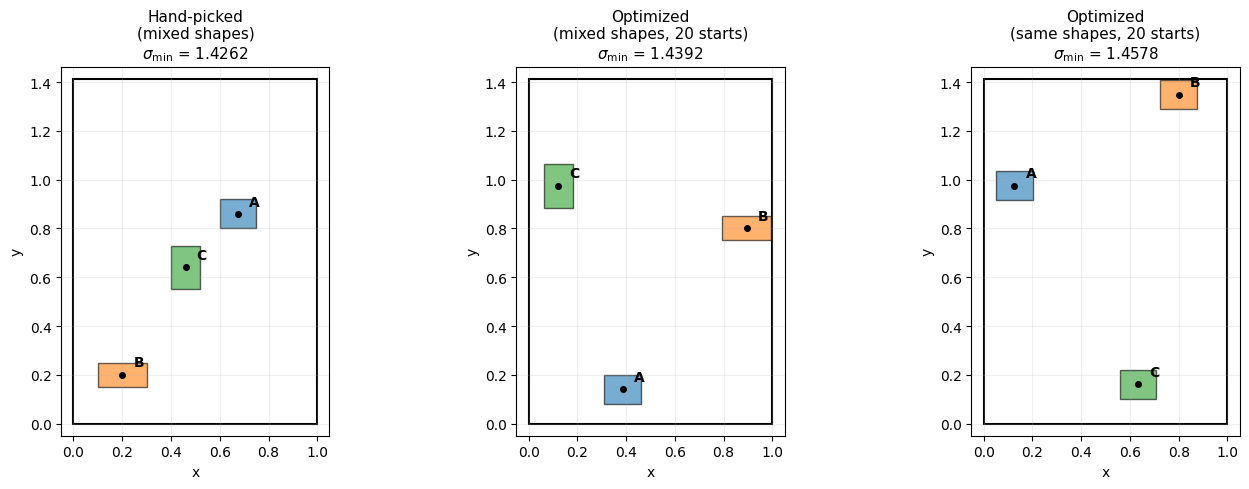

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
configs = [(positions_std, sizes_std,    "Hand-picked\n(mixed shapes)",          sig_std),
           (opt_global,    sizes_std,    "Optimized\n(mixed shapes, 20 starts)", best[0]),
           (opt_same,      sizes_same,   "Optimized\n(same shapes, 20 starts)",  best_same[0])]
colors = ["tab:blue", "tab:orange", "tab:green"]

for ax, (pos, sizes, title, sig) in zip(axes, configs):
    ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
    for k, ((x0, y0), (aa, bb)) in enumerate(zip(pos, sizes)):
        ax.add_patch(plt.Rectangle((x0-aa/2, y0-bb/2), aa, bb, alpha=0.6,
                                   edgecolor="black", facecolor=colors[k]))
        ax.plot(x0, y0, "ko", markersize=4)
        ax.annotate(['A','B','C'][k], (x0, y0), textcoords="offset points",
                    xytext=(8, 6), fontsize=10, fontweight="bold")
    ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05); ax.set_aspect("equal")
    ax.set_title(f"{title}\n$\\sigma_{{\\min}}$ = {sig:.4f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## What to take away

**The pattern transfers almost unchanged.** Adjoint methods for $\sigma_\min$ of stacked operators reuse Notebook 1's pattern with one modification: bilinear integrand $u_k\,v$ instead of quadratic $|\psi|^2$. The Reynolds-transport edge structure is identical.

**Eigenvalues vs singular values.** When the operator is symmetric PSD, you can work with eigenvalues (one vector). When it isn't (rectangular, non-self-adjoint), you need singular values (two vectors). Same conceptual content, different bookkeeping. Get comfortable with both.

**Sign tracking matters.** Our $A = I - K$ flipped the sign of the gradient relative to Notebook 1's $K$ alone. FD verification catches this immediately; trying to optimize with the wrong sign would have wandered the wrong direction and reported "converged" at a non-optimum.

**Multi-DOF verification scales.** $2d$ forward solves regardless of dimension. The cost is trivial; the cost of an undetected sign error scales with debugging time, which is decidedly not trivial.

**Run the ablations.** When your design space has multiple kinds of variation, optimize over each separately. Sometimes the kind you thought was important isn't. The framework's "shape diversity" intuition was reasonable but wrong; only running the comparison reveals it.

**The next notebook** introduces *constraints* — area-preserving shape variation. The new ingredients are the chain rule for the area constraint and the diagnostic for "no interior optimum" (the optimum runs to a bound and keeps going as you widen the bound).
